In [1]:
from pymatgen.io.phonopy import get_gruneisen_ph_bs_symm_line, get_gruneisenparameter
from pymatgen.phonon.plotter import GruneisenPhononBandStructureSymmLine, GruneisenPhononBSPlotter, GruneisenPlotter
import scipy.constants as const
import matplotlib.pyplot as plt

In [2]:
gru_rt=get_gruneisenparameter(gruneisen_path='RT/gruneisen_mesh.yaml')

In [3]:
gps = GruneisenPlotter(gru_rt)

In [4]:
from collections import namedtuple
import matplotlib.pyplot as plt
from pymatgen.util.plotting import add_fig_kwargs, get_ax_fig, get_axarray_fig_plt, pretty_plot
FreqUnits = namedtuple("FreqUnits", ["factor", "label"])

def freq_units(units):
    """

    Args:
        units: str, accepted values: thz, ev, mev, ha, cm-1, cm^-1

    Returns:
        Returns conversion factor from THz to the required units and the label in the form of a namedtuple

    """

    d = {
        "thz": FreqUnits(1, "THz"),
        "ev": FreqUnits(const.value("hertz-electron volt relationship") * const.tera, "eV"),
        "mev": FreqUnits(
            const.value("hertz-electron volt relationship") * const.tera / const.milli,
            "meV",
        ),
        "ha": FreqUnits(const.value("hertz-hartree relationship") * const.tera, "Ha"),
        "cm-1": FreqUnits(
            const.value("hertz-inverse meter relationship") * const.tera * const.centi,
            "cm^{-1}",
        ),
        "cm^-1": FreqUnits(
            const.value("hertz-inverse meter relationship") * const.tera * const.centi,
            "cm^{-1}",
        ),
    }
    try:
        return d[units.lower().strip()]
    except KeyError:
        raise KeyError(f"Value for units `{units}` unknown\nPossible values are:\n {list(d.keys())}")

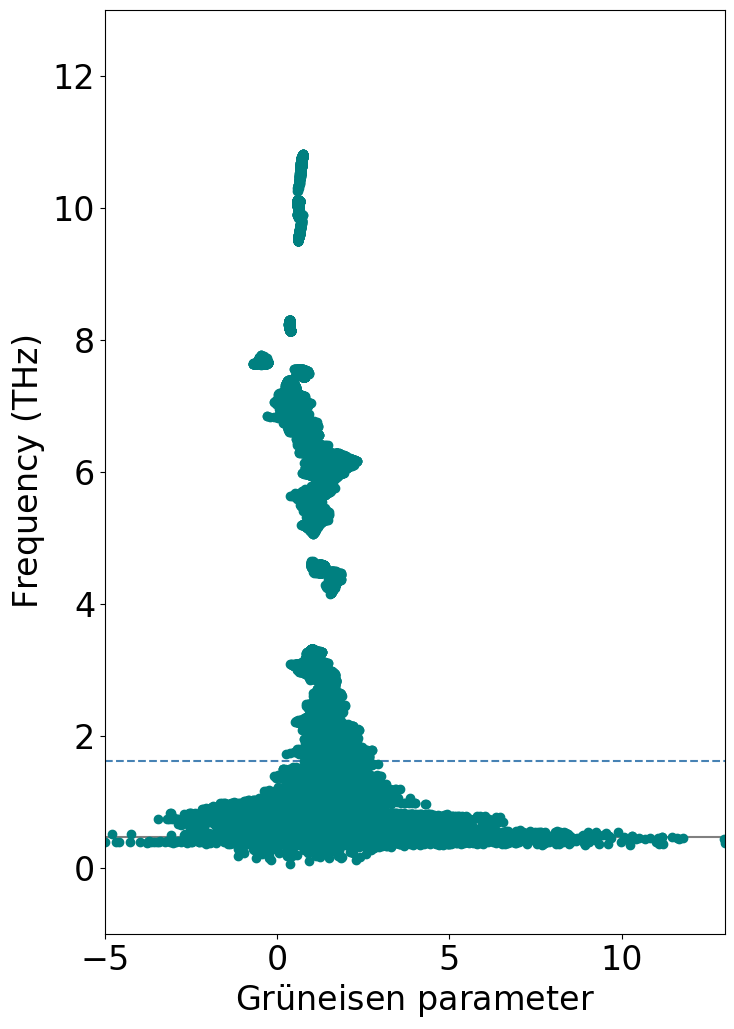

In [6]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

u = freq_units("thz")
xs = gps._gruneisen.frequencies.flatten() * u.factor
ys = gps._gruneisen.gruneisen.flatten()

ax = pretty_plot(8, 12, color_cycle=("qualitative", "Paired_3"))

ax.set_ylabel(r"$\mathrm{Frequency\ (THz)}$")
ax.set_xlabel(r"$\mathrm{Grüneisen\ parameter}$")

ax.set_xlim(-5,13)
ax.set_ylim(-1,13)
ax.axhline(gru_rt.acoustic_debye_temp* const.value("Boltzmann constant in Hz/K") *1E-12, color='steelblue', ls='--')
ax.axhline(gps._gruneisen.frequencies[2].max() * u.factor, color="gray")
ax.tick_params(axis="both", which="major", labelsize=24)   # major ticks
ax.tick_params(axis="both", which="minor", labelsize=24)   # if you use minor ticks

n = len(ys) - 1
for i, (x, y) in enumerate(zip(xs, ys)):
    color = (1.0 / n * i, 0, 1.0 / n * (n - i))
   
    ax.plot(y, x, 'o', color='teal')
    
plt.savefig('RT_plot.pdf')

In [7]:
gru_LT=get_gruneisenparameter(gruneisen_path='LT/gruneisen_mesh.yaml')

In [8]:
gps_LT = GruneisenPlotter(gru_LT)

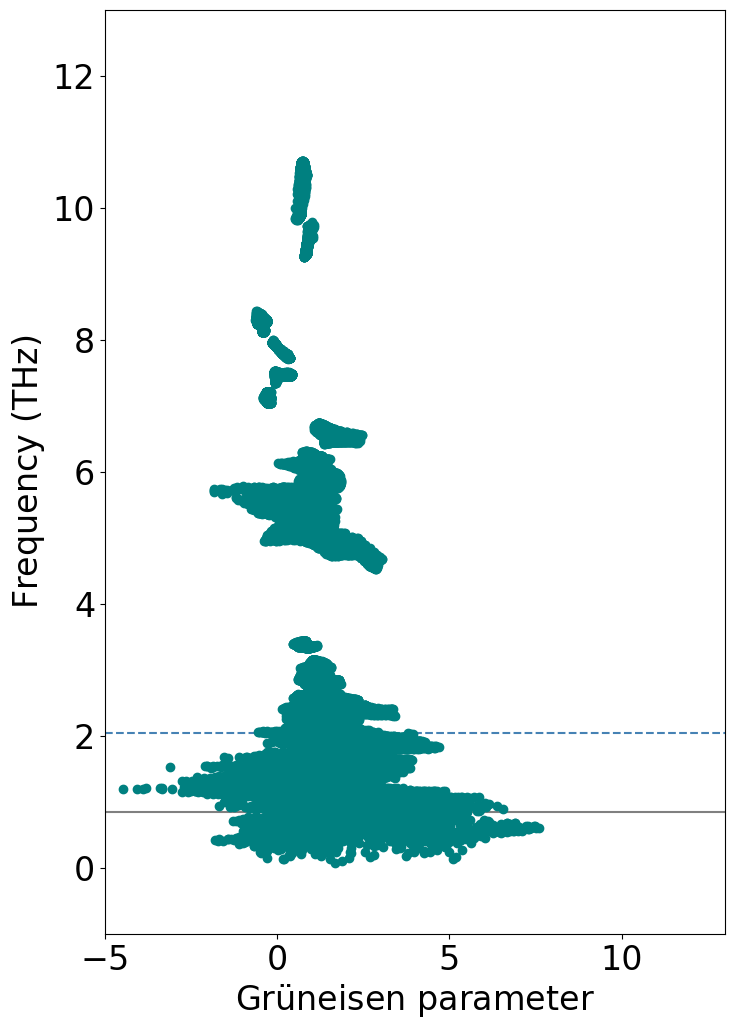

In [9]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
u = freq_units("thz")

xs_LT = gps_LT._gruneisen.frequencies.flatten() * u.factor
ys_LT = gps_LT._gruneisen.gruneisen.flatten()

ax = pretty_plot(8, 12, color_cycle=("qualitative", "Paired_3"))


ax.set_ylabel(r"$\mathrm{Frequency\ (THz)}$")
ax.set_xlabel(r"$\mathrm{Grüneisen\ parameter}$")
ax.set_xlim(-5,13)
ax.set_ylim(-1,13)
ax.axhline(gru_LT.acoustic_debye_temp* const.value("Boltzmann constant in Hz/K") *1E-12, color='steelblue', ls='--')
ax.axhline(gps_LT._gruneisen.frequencies[2].max() * u.factor, color="gray")
ax.tick_params(axis="both", which="major", labelsize=24)   # major ticks
ax.tick_params(axis="both", which="minor", labelsize=24)   # if you use minor ticks

n = len(ys) - 1
for i, (x, y) in enumerate(zip(xs_LT, ys_LT)):
    color = (1.0 / n * i, 0, 1.0 / n * (n - i))

    
    ax.plot(y, x, 'o', color='teal')
plt.savefig('LT.pdf')

In [10]:
gru_Si=get_gruneisenparameter(gruneisen_path='Si/gruneisen_mesh.yaml')

In [11]:
gps_Si = GruneisenPlotter(gru_Si)

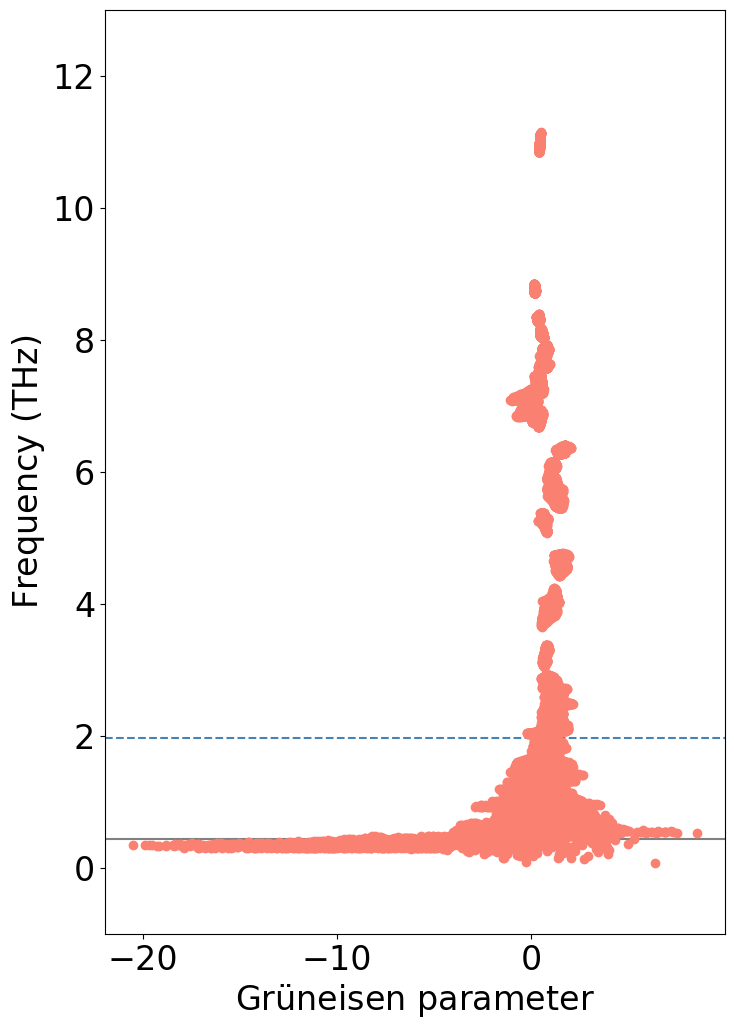

In [12]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
u = freq_units("thz")

xs_Si = gps_Si._gruneisen.frequencies.flatten() * u.factor
ys_Si = gps_Si._gruneisen.gruneisen.flatten()

ax = pretty_plot(8, 12, color_cycle=("qualitative", "Paired_3"))

ax.set_ylabel(r"$\mathrm{Frequency\ (THz)}$")
ax.set_xlabel(r"$\mathrm{Grüneisen\ parameter}$")
ax.set_ylim(-1,13)
ax.axhline(gru_Si.acoustic_debye_temp* const.value("Boltzmann constant in Hz/K") *1E-12, color='steelblue', ls='--')
ax.axhline(gps_Si._gruneisen.frequencies[2].max(), color="gray")
ax.tick_params(axis="both", which="major", labelsize=24)   # major ticks
ax.tick_params(axis="both", which="minor", labelsize=24)   # if you use minor ticks
n = len(ys_Si) - 1
for i, (x, y) in enumerate(zip(xs_Si, ys_Si)):
    color = (1.0 / n * i, 0, 1.0 / n * (n - i))

    
    ax.plot(y, x, 'o', color='salmon')
plt.savefig('Si.pdf')

In [13]:
gru_Ge=get_gruneisenparameter(gruneisen_path='Ge/gruneisen_mesh.yaml')

In [14]:
gps_Ge = GruneisenPlotter(gru_Ge)

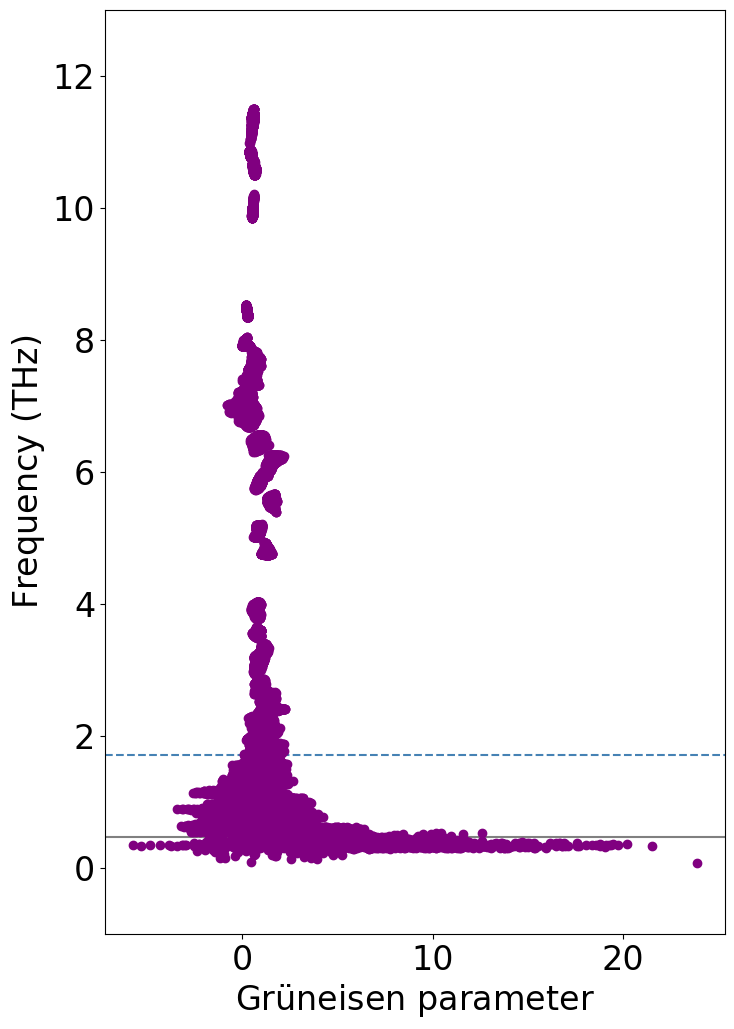

In [15]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
u = freq_units("thz")

xs_Ge = gps_Ge._gruneisen.frequencies.flatten() * u.factor
ys_Ge = gps_Ge._gruneisen.gruneisen.flatten()

ax = pretty_plot(8, 12, color_cycle=("qualitative", "Paired_3"))

ax.set_ylabel(r"$\mathrm{Frequency\ (THz)}$")
ax.set_xlabel(r"$\mathrm{Grüneisen\ parameter}$")
ax.set_ylim(-1,13)
ax.axhline(gru_Ge.acoustic_debye_temp* const.value("Boltzmann constant in Hz/K") *1E-12, color='steelblue', ls='--' )
ax.axhline(gps_Ge._gruneisen.frequencies[2].max(), color="gray")
ax.tick_params(axis="both", which="major", labelsize=24)   # major ticks
ax.tick_params(axis="both", which="minor", labelsize=24)   # if you use minor ticks

n = len(ys_Ge) - 1
for i, (x, y) in enumerate(zip(xs_Ge, ys_Ge)):
    color = (1.0 / n * i, 0, 1.0 / n * (n - i))

    
    ax.plot(y, x, 'o', color='purple')
plt.savefig('Ge.pdf')